<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# II. Análise de extensões. Extensometria. Equações da compatibilidade.

## Problema 7 <a name="PII57"></a>

Um corpo está sujeito ao seguinte campo de deslocamentos (unidades em mm):

\begin{equation*}
	\begin{aligned}
	u &= Ax + 0.0003y \\
	v &= 0.0003x - By \\
	w &= 0.005 \\
	\end{aligned}
\end{equation*}

[a)](#A) Determine o tensor das deformações infinitesimais e caracterize o estado de tensão obtido.

[b)](#B) Determine a relação entre $A$ e $B$ para a qual a deformação não apresenta variação de volume.

[c)](#C) Considere agora $A = B = 200 \mu$. Calcule as extensões principais e as respectivas direções 	principais de extensão.


## Resolução

#### a) Determine o tensor das deformações infinitesimais e caracterize o estado de tensão obtido.<a name="A"></a>

([enunciatum](#PII57))

As componentes cartesianas do tensor das deformações infinitésimais, num dado sistema de coordenadas, podem ser obtidas
pelas derivadas parciais do campo de deslocamentos através das seguintes relações (notação indicial):

\begin{equation*}
\varepsilon_{ij} = \frac{1}{2}\left( \frac{\partial u_i}{\partial x_j}
+ \frac{\partial u_j}{\partial x_i} \right)
\end{equation*}

onde, explicitamente:

\begin{equation*}
\begin{aligned}
\varepsilon_{xx} &= \frac{\partial u}{\partial x} \\
\varepsilon_{yy} &= \frac{\partial v}{\partial y} \\
\varepsilon_{zz} &= \frac{\partial w}{\partial z} \\
\varepsilon_{xy} &= \frac{1}{2}\left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right)  = \frac{1}{2}\gamma_{xy}\\
\varepsilon_{yz} &= \frac{1}{2}\left( \frac{\partial v}{\partial z} + \frac{\partial w}{\partial y} \right)  = \frac{1}{2} \gamma_{yz}\\
\varepsilon_{xz} &= \frac{1}{2}\left( \frac{\partial u}{\partial z} + \frac{\partial w}{\partial x} \right) = \frac{1}{2} \gamma_{xz}\\
\end{aligned}
\end{equation*}

Na forma matricial, a matriz do tensor das deformações vem expressa por:

\begin{equation*}
\begin{aligned}
\underline{\underline{\varepsilon}} \equiv [\varepsilon] \equiv \varepsilon_{ij}
&=
\begin{bmatrix}
\varepsilon_{xx} & \varepsilon_{xy} & \varepsilon_{xz}\\
\varepsilon_{yx} & \varepsilon_{yy} & \varepsilon_{yz} \\
\varepsilon_{zx} & \varepsilon_{zy} & \varepsilon_{zz} \\
\end{bmatrix} =
\begin{bmatrix}
\varepsilon_{xx} & \gamma_{xy}/2 & \gamma_{xz}/2 \\
\gamma_{yx}/2 & \varepsilon_{yy} & \gamma_{yz}/2 \\
\gamma_{zx}/2 & \gamma_{yz}/2 & \varepsilon_{zz} \\
\end{bmatrix} \\
&=
\begin{bmatrix}
\displaystyle\frac{\partial u}{\partial x}
& \displaystyle\frac{1}{2}\left(\frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right)
& \displaystyle\frac{1}{2}\left(\frac{\partial u}{\partial z} + \frac{\partial w}{\partial x} \right) \\
\displaystyle\frac{1}{2}\left(\frac{\partial v}{\partial x} + \frac{\partial u}{\partial y} \right)
& \displaystyle\frac{\partial v}{\partial y}
& \displaystyle\frac{1}{2}\left(\frac{\partial v}{\partial z} + \frac{\partial w}{\partial y} \right) \\
\displaystyle\frac{1}{2}\left(\frac{\partial w}{\partial x} + \frac{\partial u}{\partial z} \right)
& \displaystyle\frac{1}{2}\left(\frac{\partial v}{\partial z} + \frac{\partial w}{\partial y} \right)
& \displaystyle\frac{\partial w}{\partial z} \\
\end{bmatrix}
\end{aligned}
\end{equation*}

De notar que a definição geométrica da dirtorção ou deformação de corte de engenharia $\gamma_{ij}$ como a variação ângular de um elemento quadrado infinitésimal, implica que a dirtorção tensorial $\varepsilon_{ij}$ verifique a seguinte
relação:

\begin{equation*}
\gamma_{ij} = 2 \varepsilon_{ij}
\end{equation*}

Esta relação é importante nomeadamente pela consistência da lei de transformação do tensor de deformação (de segunda ordem e simétrico).

In [35]:
import numpy as np
import sympy as sy
from sympy import symbols, collect, diff, Derivative
from sympy.solvers import solve
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
from pylab import meshgrid,cm,imshow,contour,clabel,colorbar,axis,title,show

u, v, w, x, y, z, A, B = symbols('u v w x y z A B')

a010 = 0.0003
b100 = 0.0003
b003 = 0.002
c000 = 0.005

def u(x,y,A): return A*x + a010*y
def v(x,y,B): return b100*x - B*y
def w(): return c000

u1 = u(x,y,A)
v1 = v(x,y,B)
w1 = w()

def u2eps(ux,uy,uz):
    exx = diff(ux, x)
    eyy = diff(uy, y)
    ezz = diff(uz, z)
    exy  = 0.5*(diff(ux, y) + diff(uy, x))
    exz  = 0.5*(diff(ux, z) + diff(uz, x))
    eyz  = 0.5*(diff(uy, z) + diff(uz, y))

    return np.array([[exx,exy,exz],[exy,eyy,eyz],[exz,eyz,ezz]])

# componentes cartesianas da matriz das deformações
print('\nMatriz das deformações, [D] :')
mD0 = u2eps(u1,v1,w1)
print(mD0)


Matriz das deformações, [D] :
[[A 0.000300000000000000 0]
 [0.000300000000000000 -B 0]
 [0 0 0]]


O campo de deslocamentos enunciado corresponde a um estado de deformação/tensão plano:

\begin{equation*}
\underline{\underline{\varepsilon}}
\equiv \varepsilon_{ij} =
\begin{bmatrix}
A & 0.0003 & 0 \\
0.0003 & -B & 0 \\
0 & 0 & 0
\end{bmatrix}
\end{equation*}

#### b) Determine a relação entre $A$ e $B$ para a qual a deformação não apresenta variação de volume.<a name="B"></a>

([enunciatum](#PII57))

O coeficiente de extensão volumétrico ou dilatação é dado por:

\begin{equation*}
\varepsilon_\mathrm{v} = \frac{\Delta V}{V} = \frac{V'-V_0}{V_0}
\end{equation*}

em que $V'$ é o volume final do corpo deformado, $V_0$ é o volume inicial do corpo não deformado. Esta
relação pode ser aproximada por:

\begin{equation*}
\begin{aligned}
V' & \approx (1+\varepsilon_{xx}+\varepsilon_{yy}+\varepsilon_{zz} )V_0 \\
\end{aligned}
\end{equation*}

cujo desenvolvimento algébrico conduz a,

\begin{equation*}
\begin{aligned}
\frac{V'}{V} -1 &= \varepsilon_{xx}+\varepsilon_{yy}+\varepsilon_{zz} \\
\frac{V'-V}{V}&= \varepsilon_{xx}+\varepsilon_{yy}+\varepsilon_{zz}
\end{aligned}
\end{equation*}

Sendo que

\begin{equation*}
\begin{aligned}
\varepsilon_\mathrm{v} = \frac{V'-V}{V} \quad\textrm{e}\quad I_\mathrm{\varepsilon} =
 \varepsilon_{xx}+\varepsilon_{yy}+\varepsilon_{zz} \\
\end{aligned}
\end{equation*}

resulta que, no caso de deformação em volume constante, o primeiro invariante da matriz do tensor de deformação deve ser
nulo,

\begin{equation*}
\begin{aligned}
\varepsilon_\mathrm{v} &\equiv I_\mathrm{\varepsilon} = \varepsilon_{xx}+\varepsilon_{yy}+\varepsilon_{zz}=0
\end{aligned}
\end{equation*}

In [36]:
I1 = np.trace(mD0)
sol = solve(I1,A)
print('Condição de dilatação nula: ------------')
print('I1 = ',I1,' = 0')
print('A = ',sol[0])

Condição de dilatação nula: ------------
I1 =  A - B  = 0
A =  B


#### c) Considere agora $A = B = 200 \mu$. Calcule as extensões principais e as respectivas direcções principais de extensão.<a name="C"></a>

([enunciatum](#PII57))

O estado de deformação instalado corresponde a um estado plano de deformação no sistema de coordenadas
$S(0,x,y,z)$ para o qual se verifica:

\begin{equation*}
\varepsilon_{zz} = \gamma_{xz} = \gamma_{yz} = 0
\end{equation*}

Pelo que os únicos elementos não nulos da matriz do tensor das deformações são as componentes:
$\varepsilon_{xx}, \varepsilon_{yy}, \gamma_{xy}$.

Para uma fibra (elemento de linha ou segmento de reta) $\overrightarrow{PQ}$ no plano $x-y$, com cosenos diretores
$n_x$ e $n_y$, a deformação linear infinitésimal é dada por:

\begin{equation*}
\varepsilon_\mathrm{PQ} = \varepsilon_{xx}n_x^2 + \varepsilon_{yy}n_y^2 + \gamma_{xy}n_xn_y
\end{equation*}

se o segmento $\overrightarrow{PQ}$ estiver rodado de um ângulo $\theta$ em relação ao eixo dos $xx$, a extensão linear
é função apenas desse ângulo, resultando a seguinte expressão simplificada:

\begin{equation*}
\varepsilon_\mathrm{PQ} = \varepsilon_{xx}\cos^2\theta + \varepsilon_{yy}\sin^2\theta
+ \frac{1}{2}\gamma_{xy}\sin2\theta
\end{equation*}

As deformações principais para um elemento plano de deformação representam as extensões máxima e minima que ocurrem num
determinado ponto material do objeto. Estes valores podem ser obtidos usando expressões de transformação do tensor das
deformações ou recorrendo ao método da circunferência de Mohr.

Dadas as componentes cartesianas do tensor de deformação num referencial
$S(0,x,y),~(\varepsilon_{xx}, \varepsilon_{yy}, \gamma_{xy}$),
as extensões principais no plano $x-y$ podem ser determinadas pelas seguintes equações:

\begin{equation*}
\varepsilon_{\mathrm{P1,P2}} = \frac{\varepsilon_{xx} + \varepsilon_{yy}}{2} \pm \sqrt{\left(\frac{\varepsilon_{xx} -
\varepsilon_{yy}}{2}\right)^2 + \left(\frac{\gamma_{xy}}{2}\right)^2}
\end{equation*}

Em relação ao método do círculo de Mohr, podem definir-se o centro e raio da circunferência pelas expressões:

\begin{equation*}
\bar{\varepsilon} = \frac{\varepsilon_{xx} + \varepsilon_{yy}}{2} \quad\quad R = \sqrt{\left(\frac{\varepsilon_{xx} -
\varepsilon_{yy}}{2}\right)^2 + \left(\frac{\gamma_{xy}}{2}\right)^2}
\end{equation*}

In [37]:
u2 = u1.subs({x:x, y:y, A:200e-6})
v2 = v1.subs({x:x, y:y, B:200e-6})
w2 = w1

print('\nMatriz das deformações, [D] :')
mD2 = u2eps(u2,v2,w2)
print(mD2)

def epsavg(ex,ey): return (ex + ey)/2

def epsradius(ex,ey,gxy): return np.sqrt( ((ex - ey)/2)**2 + (gxy/2)**2)

exx = float(mD2[0,0])
eyy = float(mD2[1,1])
exy = float(mD2[0,1])
gxy = 2*exy

epsmedio = epsavg(exx,eyy)
epsraio = epsradius(exx,eyy,gxy)
epsmax = epsmedio + epsraio
print('Eps max = ','{:.5e}'.format(epsmax))
epsmin = epsmedio - epsraio
print('Eps min = ','{:.5e}'.format(epsmin))


Matriz das deformações, [D] :
[[0.000200000000000000 0.000300000000000000 0]
 [0.000300000000000000 -0.000200000000000000 0]
 [0 0 0]]
Eps max =  3.60555e-04
Eps min =  -3.60555e-04


Pela análise do circulo de Mohr:


PLANO x-y:
  Deformação normal mínima:  -3.61000e-04
  Deformação normal máxima:  3.61000e-04
  Deformação normal média :  0.00000e+00
Deformação de corte mínima:  -3.61000e-04
Deformação de corte máxima:  3.61000e-04
Ponto A ( 2.00000e-04 , 3.00000e-04 )
Ponto B ( -2.00000e-04 , -3.00000e-04 )


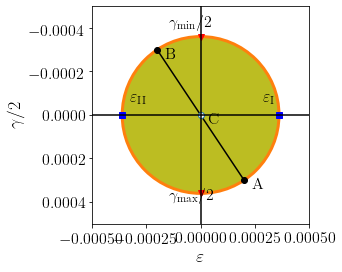

In [38]:
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 16
rc('text', usetex=True)

def mohr(E,limits):
    """Plot Mohr circle for a 2D tensor"""
    E11 = E[0][0]
    E12 = E[0][1]
    E22 = E[1][1]
    center = [(E11 + E22)/2.0, 0.0]
    radius = np.sqrt((E11 - E22)**2/4.0 + E12**2)
    Emin = center[0] - radius
    Emax = center[0] + radius

    print("  Deformação normal mínima: ", '{:.5e}'.format(np.round(Emin,6)))
    print("  Deformação normal máxima: ", '{:.5e}'.format(np.round(Emax, 6)))
    print("  Deformação normal média : ", '{:.5e}'.format(np.round(center[0], 6)))
    print("Deformação de corte mínima: ", '{:.5e}'.format(np.round(-radius, 6)))
    print("Deformação de corte máxima: ", '{:.5e}'.format(np.round(radius, 6)))

    print('Ponto A (','{:.5e}'.format(E11),',','{:.5e}'.format(E12),')')
    print('Ponto B (','{:.5e}'.format(E22),',','{:.5e}'.format(-E12),')')

    circ = plt.Circle((center[0],0), radius, facecolor='tab:olive', lw=3,
    edgecolor='tab:orange')
    desv = 0.1*radius
    plt.axis('image')
    ax = plt.gca()
    ax.add_artist(circ)
    ax.set_xlim(Emin - .3*radius, Emax + .3*radius)
    ax.set_ylim(-1.3*radius, 1.3*radius)
    plt.plot([E11, E22], [E12, -E12], 'ko')
    plt.plot([E11, E22], [E12, -E12], 'k')
    plt.plot(Emin, 0, 'bs')
    plt.plot(Emax, 0, 'bs')
    plt.plot(center[0], radius, 'rv')
    plt.plot(center[0], -radius, 'rv')
    plt.plot(center[0], center[1], 'o', mfc='w')
    plt.text(center[0]+desv, desv, 'C')
    plt.text(E11 + desv, E12 + desv , 'A')
    plt.text(E22 + desv, -E12 + desv, 'B')
    plt.text(Emin + .1*radius, -0.15*radius, r'$\varepsilon_\mathrm{II}$')
    plt.text(Emax - .2*radius, -0.15*radius, r'$\varepsilon_\mathrm{I}$')
    plt.text(center[0]-4*desv, 1.1*radius, r'$\gamma_\mathrm{max}/2$')
    plt.text(center[0]-4*desv, -1.1*radius, r'$\gamma_\mathrm{min}/2$')
    plt.xlabel(r"$\varepsilon$", size=18)
    plt.ylabel(r"$\gamma/2$", size=18)
    plt.xlim(limits[0,0],limits[0,1])
    plt.ylim(limits[1,0],limits[1,1])
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    plt.show()

axislim = np.array([[-5e-4,5e-4],[--5e-4,-5e-4]])
print('\n================================')
print('PLANO x-y:')
print('================================')
E1 = np.array([[exx, exy],[exy, eyy]])
mohr(E1, axislim)

As deformações principais:

\begin{equation*}
\begin{aligned}
\underline{\underline{\varepsilon}}_\mathrm{P} &=
\begin{bmatrix}
3.60555e-04  & 0 \\
0 & -3.60555e-04
\end{bmatrix}
\end{aligned}
\end{equation*}

Uma vez conhecidas as deformações principais é possível determinar as direções principais onde estas atuam.
Para determinar os ângulos ou cosenos diretores associados às deformações principais, é possível usar uma expressão
simples relacionando a dirtorção de corte ($\gamma_{xy}$) com as extensões normais
($\varepsilon_{xx}$, $\varepsilon_{yy}$):

\begin{equation*}
\tan2\theta_\mathrm{P1} = \frac{\gamma_{xy}}{\varepsilon_{xx} - \varepsilon_{yy}}
\end{equation*}

e

\begin{equation*}
2\theta_\mathrm{P2} = 2\theta_\mathrm{P1} + 2(90^\circ)
\end{equation*}

Após obter os valores dos ângulos principais $(\theta_\mathrm{P1}, \theta_\mathrm{P2})$ é necessário calcular o valor
da deformação linear para cada valor de ângulo para determinar a que deformação principal um determinado ângulo está
associada.

\begin{equation*}
\varepsilon_{\mathrm{P1,P2}} = \varepsilon_{xx}\cos^2(\theta_{\mathrm{P1,P2}}) +
\varepsilon_{yy}\sin^2(\theta_{\mathrm{P1,P2}}) + \gamma_{xy}\sin(\theta_{\mathrm{P1,P2}})\cos(\theta_{\mathrm{P1,P2}})
\end{equation*}

In [39]:
print('\n================================')
print('Direcões principais :')
print('================================')
def angP(e11,e22,g12): return np.arctan((g12)/(e11-e22))

aP1 = angP(exx,eyy,gxy)
aP2 = aP1 + np.pi

print('angulos das direções principais')
print('\nNo espaço das tensões:')
print('angPI  = ','{:.3f}'.format(np.rad2deg(aP1)),' deg | ','{:.3f}'.format(aP1),' radians')
print('angPII = ','{:.3f}'.format(np.rad2deg(aP2)),' deg | ','{:.3f}'.format(aP2),' radians')

aPI = aP1/2
aPII = aP2/2

print('\nNo espaço fisico:')
print('angPI  =  ','{:.3f}'.format(np.rad2deg(aPI)),' deg | ','{:.3f}'.format(aPI),' radians')
print('angPII = ','{:.3f}'.format(np.rad2deg(aPII)),' deg | ','{:.3f}'.format(aPII),' radians')

def Q(ang,rot):
    c = np.cos(ang)
    s = np.sin(ang)
    if rot == 1:
        Qij = np.array([[1,0,0],[0,c,s],[0,-s,c]])
    elif rot == 2:
        Qij = np.array([[c,0,s],[0,1,0],[-s,0,c]])
    else:
        Qij = np.array([[c,s,0],[-s,c,0],[0,0,1]])
    return Qij

MatrTrans = Q(aPI,3)
print('\nMatriz de transformação = \n',MatrTrans)

print('\nVetores principais:')
nI = MatrTrans[0,:]
print('eI = ', nI)
nII = MatrTrans[1,:]
print('eII = ', nII)
nIII = MatrTrans[2,:]
print('eIII = ', nIII)

print('\nDireções (ângulos) principais associados às deformações principais:---------')

def ext(eXX,eYY,gXY,t): return eXX*np.cos(t)**2 + eYY*np.sin(t)**2 + gXY*np.sin(t)*np.cos(t)

extPI = ext(exx,eyy,gxy,aPI)
print('direção principal: ','{:.3f}'.format(np.rad2deg(aPI)),' - deformação principal : ','{:.5e}'.format(extPI))
extPII = ext(exx,eyy,gxy,aPII)
print('direção principal: ','{:.3f}'.format(np.rad2deg(aPII)),' - deformação principal : ','{:.5e}'.format(extPII))


Direcões principais :
angulos das direções principais

No espaço das tensões:
angPI  =  56.310  deg |  0.983  radians
angPII =  236.310  deg |  4.124  radians

No espaço fisico:
angPI  =   28.155  deg |  0.491  radians
angPII =  118.155  deg |  2.062  radians

Matriz de transformação = 
 [[ 0.8816746   0.47185793  0.        ]
 [-0.47185793  0.8816746   0.        ]
 [ 0.          0.          1.        ]]

Vetores principais:
eI =  [0.8816746  0.47185793 0.        ]
eII =  [-0.47185793  0.8816746   0.        ]
eIII =  [0. 0. 1.]

Direções (ângulos) principais associados às deformações principais:---------
direção principal:  28.155  - deformação principal :  3.60555e-04
direção principal:  118.155  - deformação principal :  -3.60555e-04


**Distorção angular principal ou máxima**

A deformação de corte máxima/mínima é uma quantidade importante. Ela é usada, por exemplo, no dimensionameto de chavetas em
uniões de veios. A distorção angular máxima/mínima pode ser obtida pela relação:

\begin{equation*}
\frac{\gamma_\mathrm{P}}{2} = \pm\sqrt{ \left(\frac{\varepsilon_{xx} - \varepsilon_{yy}}{2} \right)^2 +
\left( \frac{\gamma_{xy}}{2} \right)^2 }
\end{equation*}

In [40]:
def distangularP(exx,eyy,gxy): return 2*np.sqrt( ((exx-eyy)/2)**2 + (gxy/2)**2 )

corteP = distangularP(exx,eyy,gxy)
print('Distorção angular principal (máximo/mínimo) : +/-','{:.5e}'.format(corteP))

Distorção angular principal (máximo/mínimo) : +/- 7.21110e-04


A partir dos valors extremos é possível determinar os ângulos de orientação onde ocorrem as deformações de corte
máxima/mínima. É possível calcular os ângulos de corte principais pela expressão:

\begin{equation*}
\begin{aligned}
\tan2\theta_\mathrm{S_1} &=
\frac{-(\varepsilon_{xx} - \varepsilon_{yy}) }{ \gamma_{xy} } \\
2\theta_\mathrm{S_2} &= 2\theta_\mathrm{S_1} + 2(90^\circ)
\end{aligned}
\end{equation*}

In [41]:
def gammax1y1(eXX,eYY,gXY,t): return -(eXX - eYY)*np.sin(2*t) + gXY*np.cos(2*t)
def angShearMax(exx,eyy,gxy): return np.arctan( -(exx-eyy)/gxy )

corteAngP1 = angShearMax(exx,eyy,gxy)/2
corteAngP2 = corteAngP1 + np.pi/2
print('Orientação do angular principal (máximo/mínimo) : ','{:.2f}'.format(np.rad2deg(corteAngP1)))
print('Orientação do angular principal (máximo/mínimo) : ','{:.2f}'.format(np.rad2deg(corteAngP2)))

check1 = gammax1y1(exx,eyy,gxy,corteAngP1)
print('Àngulo I: ','{:.2f}'.format(np.rad2deg(corteAngP1)),' | tens corte max: ','{:.5e}'.format(check1))
check2 = gammax1y1(exx,eyy,gxy,corteAngP2)
print('Àngulo II: ','{:.2f}'.format(np.rad2deg(corteAngP2)),' | tens corte min: ','{:.5e}'.format(check2))

Orientação do angular principal (máximo/mínimo) :  -16.85
Orientação do angular principal (máximo/mínimo) :  73.15
Àngulo I:  -16.85  | tens corte max:  7.21110e-04
Àngulo II:  73.15  | tens corte min:  -7.21110e-04


De notar que os ângulos principais para as extensões lineares e dirtorções angulares formam entre si um ângulo de
45$^\circ$, ou seja:

\begin{equation*}
\Delta_i \theta = \theta_{P_i} - \theta_{S_i} = 45^\circ \quad i = \mathrm{I,II}
\end{equation*}

In [42]:
Dt1 = aPI - corteAngP1
print('Dt1 [Deg] = ',np.rad2deg(Dt1))
Dt2 = aPII - corteAngP2
print('Dt2 [Deg] = ',np.rad2deg(Dt2))

Dt1 [Deg] =  45.0
Dt2 [Deg] =  45.0


Variação da extensão normal com o ângulo definido pela direção $x_1$ e a o eixo horizonal $x_0$ é dada por (Apêncide A):

\begin{equation*}
\begin{aligned}
\varepsilon_{x_1} &= \varepsilon_{xx}\cos^2\theta_{x_1} +
\varepsilon_{yy}\sin^2\theta_{x_1} + \gamma_{xy}\sin\theta_{x_1}\cos\theta_{x_1} \\
\varepsilon_{y_1} &= \varepsilon_{xx}\sin^2\theta_{x_1} +
\varepsilon_{yy}\cos^2\theta_{x_1} - \gamma_{xy}\sin\theta_{x_1}\cos\theta_{x_1} \\
\end{aligned}
\end{equation*}

Por sua vez, a equação de transformação para a distorção angular vem:

\begin{equation*}
\begin{aligned}
\varepsilon_{x_1y_1} = -\frac{\varepsilon_{xx}-\varepsilon_{yy}}{2}\sin2\theta_{x_1} +
\varepsilon_{xy}\cos2\theta_{x_1}  \\
\gamma_{x_1y_1} = -(\varepsilon_{xx}-\varepsilon_{yy})\sin2\theta_{x_1} +
\gamma_{xy}\cos2\theta_{x_1}  \\
\end{aligned}
\end{equation*}

Extensões principais: -------------------------------------------
Ângulo principal (Deg) = 28.15
            Extensão I = 3.60555e-04
           Extensão II = -3.60555e-04
   Distorção de corte  = 0.0
Distorções principais: -------------------------------------------
Ângulo principal (Deg) = 73.15
            Extensão I = 0.0
           Extensão II = 0.0
   Distorção principal = -7.21110e-04


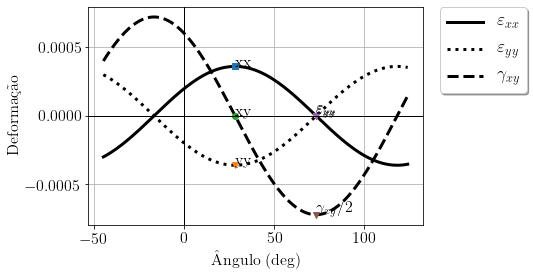

In [43]:
def epsx1(eXX,eYY,gXY,t): return eXX*np.cos(t)**2 + eYY*np.sin(t)**2 + gXY*np.sin(t)*np.cos(t)
def epsy1(eXX,eYY,gXY,t): return eXX*np.sin(t)**2 + eYY*np.cos(t)**2 - gXY*np.sin(t)*np.cos(t)
def gammax1y1(eXX,eYY,gXY,t): return -(eXX - eYY)*np.sin(2*t) + gXY*np.cos(2*t)

tang = np.arange(-45,125,1)
# extensões normais
extXang = epsx1(exx,eyy,gxy,np.deg2rad(tang))
extYang = epsy1(exx,eyy,gxy,np.deg2rad(tang))
# distorção angular
distang = gammax1y1(exx,eyy,gxy,np.deg2rad(tang))

print('Extensões principais: -------------------------------------------')
epsI = epsx1(exx,eyy,gxy,aPI)
epsII = epsy1(exx,eyy,gxy,aPI)
gammaP = gammax1y1(exx,eyy,gxy,aPI)
print('Ângulo principal (Deg) =','{:.2f}'.format(np.rad2deg(aPI)))
print('            Extensão I =','{:.5e}'.format(epsI))
print('           Extensão II =','{:.5e}'.format(epsII))
print('   Distorção de corte  =','{:.1f}'.format(gammaP))

print('Distorções principais: -------------------------------------------')
epsx1ShearMin = epsx1(exx,eyy,gxy,corteAngP2)
epsy1ShearMin = epsy1(exx,eyy,gxy,corteAngP2)
corteMin = gammax1y1(exx,eyy,gxy,corteAngP2)
print('Ângulo principal (Deg) =','{:.2f}'.format(np.rad2deg(corteAngP2)))
print('            Extensão I =','{:.1f}'.format(epsx1ShearMin))
print('           Extensão II =','{:.1f}'.format(np.abs(epsy1ShearMin)))
print('   Distorção principal =','{:.5e}'.format(corteMin))

# use LaTeX fonts in the plot
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

fig, ax = plt.subplots()
ax.plot(tang, extXang, 'k-', label=r'$\varepsilon_{xx}$', linewidth=3)
ax.plot(tang, extYang, 'k:', label=r'$\varepsilon_{yy}$', linewidth=3)
ax.plot(tang, distang, 'k--', label=r'$\gamma_{xy}$', linewidth=3)

ax.plot(np.rad2deg(aPI), epsI, 's')
ax.text(np.rad2deg(aPI), epsI,'xx')
ax.plot(np.rad2deg(aPI), epsII, 'v')
ax.text(np.rad2deg(aPI), epsII,'yy')
ax.plot(np.rad2deg(aPI), gammaP, 'o')
ax.text(np.rad2deg(aPI), gammaP,'xy')

ax.plot(np.rad2deg(corteAngP2), epsx1ShearMin, 'v')
ax.text(np.rad2deg(corteAngP2), epsx1ShearMin,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(corteAngP2), epsy1ShearMin, 'v')
ax.text(np.rad2deg(corteAngP2), epsy1ShearMin,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(corteAngP2), corteMin, 'v')
ax.text(np.rad2deg(corteAngP2), corteMin,r'$\gamma_{xy}/2$')

ax.set(xlabel='Ângulo (deg)', ylabel='Deformação')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., shadow=True, fontsize=18)
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()

### Apêndice A. Transformação do tensor das deformações no plano

\begin{equation*}
[\varepsilon]_1 = [Q_{01}][\varepsilon]_0[Q_{01}]^\mathrm{T}
\end{equation*}

Explicitamente,

\begin{equation*}
\begin{bmatrix}
\varepsilon_{x'x'} & \varepsilon_{x'y'} \\
\varepsilon_{x'y'} & \varepsilon_{y'y'} \\
\end{bmatrix} =
\begin{bmatrix}
\cos\theta & \sin\theta \\
-\sin\theta  & \cos\theta \\
\end{bmatrix}
\begin{bmatrix}
\varepsilon_{xx} & \varepsilon_{xy} \\
\varepsilon_{xy} & \varepsilon_{yy} \\
\end{bmatrix}
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta  & \cos\theta \\
\end{bmatrix}
\end{equation*}

notas - relações trigonométricas:


- $\sin2\theta = 2\sin\theta\cos\theta$
- $\cos2\theta = \cos^2\theta - \sin^2\theta = 1 – 2 \sin^2\theta
= 2 \cos^2\theta – 1$
- $\cos2\theta=(\cos2\theta+1)/2$
- $\sin2\theta=(1−\cos2\theta)/2$

In [44]:
exx0, exy0, eyy0, exx1, exy1, eyy1, C, S = symbols('exx0 exy0 eyy0 exx1 exy1 eyy1 C S')

e0 = np.array([[exx0,exy0],[exy0,eyy0]])
Q01 = np.array([[C,S],[-S,C]])
print('epsxx S0 :', e0[0,0])
print('epsxy S0 :', e0[0,1])
print('epsyy S0 :', e0[1,1])

e1 = np.dot(Q01,np.dot(e0,np.transpose(Q01)))
print('epsxx S1 :', sy.expand(e1[0,0]))
print('epsxy S1 :', sy.simplify(sy.expand(e1[0,1])))
print('epsyy S1 :', sy.expand(e1[1,1]))

epsxx S0 : exx0
epsxy S0 : exy0
epsyy S0 : eyy0
epsxx S1 : C**2*exx0 + 2*C*S*exy0 + S**2*eyy0
epsxy S1 : C**2*exy0 - C*S*exx0 + C*S*eyy0 - S**2*exy0
epsyy S1 : C**2*eyy0 - 2*C*S*exy0 + S**2*exx0


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>